In [1]:
import sys
import os
import numpy as np
import pandas as pd
import time

import torch
import torch.nn as nn 
from sklearn.base import clone

sys.path.append(os.path.abspath('../src'))

from DataLoader import DataLoader as DataLoader
from DataSplitter import DataSplitter
from Transformer import Transformer
from PreProcessorSimple import PreProcessorSimple
from PreProcessorNN import PreProcessorNN
from PipelineBuilder import PipelineBuilder
from CrossValidation import CrossValidation
from TorchClassifier import TorchClassifier

In [2]:
# Data loading
data_loader = DataLoader("../data/train.csv", "../data/test.csv")
train, test = data_loader.load()

# Data splitting
data_splitter = DataSplitter(target_column="label")
X_train, X_test, y_train, y_test = data_splitter.split(train)
X, y = train.drop(columns=['label']), train['label']

In [3]:
## ML pipeline builder
pipeline_builder = PipelineBuilder(train)

## Neural Networks - Pytorch

### MLP (Multi-Layer Perceptron)

In [4]:
params = {'model_name': 'NN', 'hidden_layer_sizes': (256,128), 'learning_rate': 1e-3, 'n_epochs': 100, 'batch_size': 256}
pipeline = pipeline_builder.build(model_name="NN", params=params)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [5]:
## Hold-Out Validation score (one fold only)
cv = CrossValidation(pipeline=clone(pipeline))

#cv_score = cv.evaluate_one_fold(X_train, y_train, X_test, y_test)
#print("Holdout Validation score: ", cv_score)

## K-fold Cross-Validation 
#cv_score = cv.evaluate(X, y)
#print("K-fold CV score: ", cv_score)

In [6]:
## Hyper-parameter tunning
param_grid = {
    "model__learning_rate": [1e-4, 1e-3, 1e-2],
    "model__n_epochs": [100],
    "model__batch_size": [256],
    "model__hidden_layer_sizes": [(256,), (256,128), (256,128,64)],
}
#cv_NN_results, loss_curves, validation_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
#                                                                               reduced=True, train_size=5000, return_loss_curves=True)
#cv_NN_results

In [7]:
## Create submission using best hyper-parameters
#cv.pipeline.set_params(model__n_epochs=200)
#preds = cv.pipeline.fit(X, y).predict(test)
#submission = pd.DataFrame({"ImageId": test.index+1, "Label": preds})
#submission.to_csv("../data/submission_nn.csv", index=False)

### CNN (Convolutional Neural Network)

In [8]:
params = {'model_name': 'CNN', 'learning_rate': 1e-3, 'n_epochs': 50, 'batch_size': 256,
          'hidden_layer_sizes': (256,128), 'channels_conv_layers': (32,64), 'kernel_sizes': 3, 'pooling_size': 2, 'augmentation': True}
pipeline = pipeline_builder.build(model_name="CNN", params=params)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

Training Activated ? True


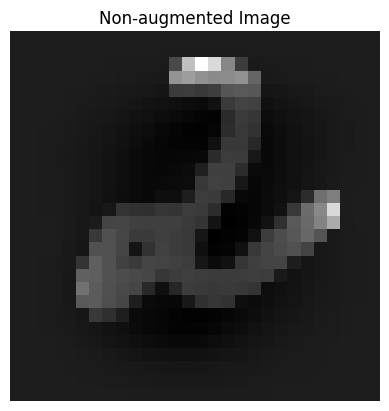

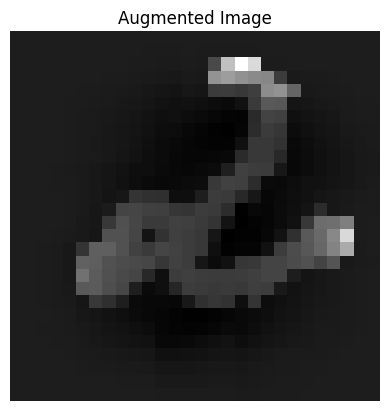

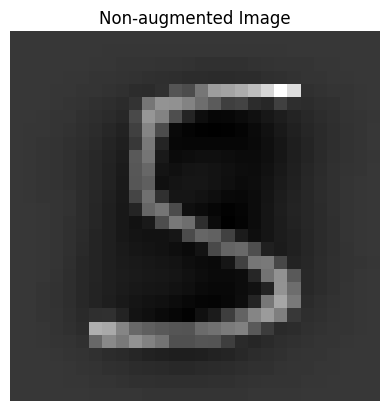

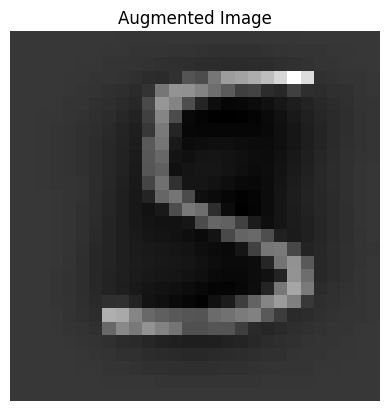

Loss after Epoch 1: 0.6172.


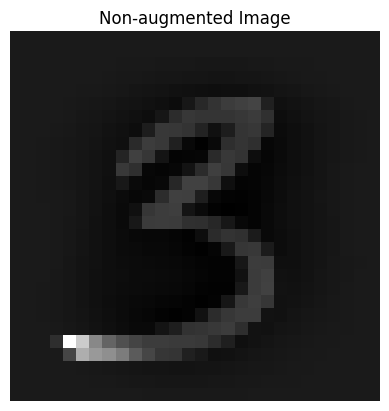

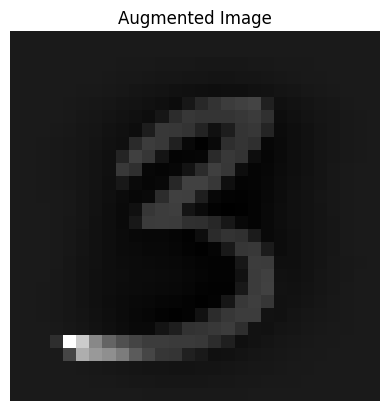

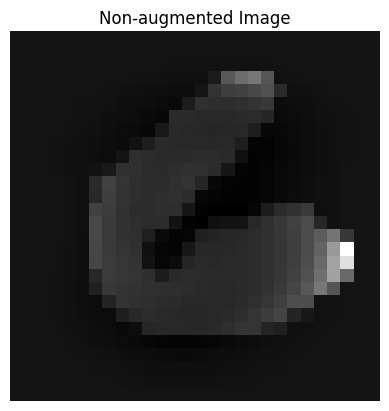

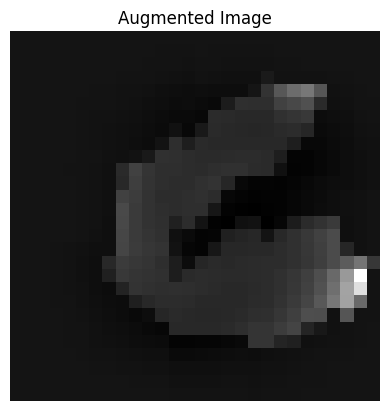

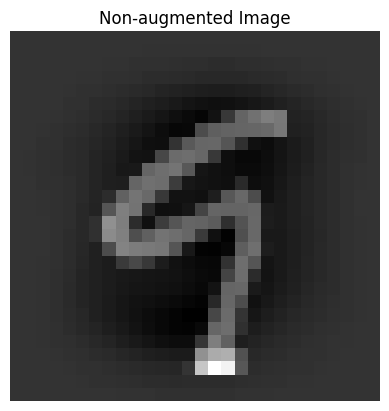

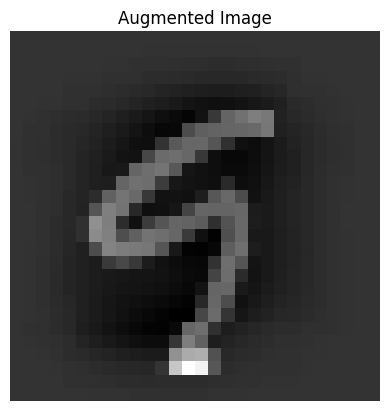

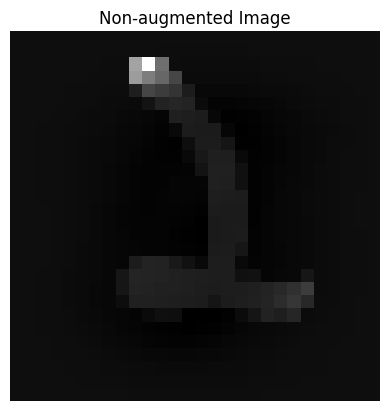

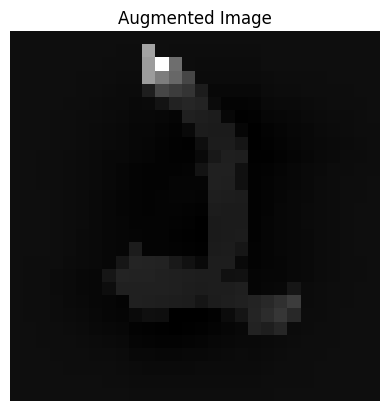

Loss after Epoch 21: 0.0406.
Loss after Epoch 41: 0.0308.
Loss after gradient descent: 0.024071.
Total Training time: 830.8570013046265.
Fit time: 835.1044280529022
Training Activated ? False
Prediction time: 3.998361825942993

Holdout Validation score:  0.9946428571428572


In [9]:
## Hold-Out Validation score (one fold only)
cv = CrossValidation(pipeline=clone(pipeline))

cv_score = cv.evaluate_one_fold(X_train, y_train, X_test, y_test)
print("Holdout Validation score: ", cv_score)

## K-fold Cross-Validation 
#cv_score = cv.evaluate(X, y)
#print("K-fold CV score: ", cv_score)

In [10]:
## Hyper-parameter tunning
param_grid = {
    "model__learning_rate": [1e-3],
    "model__n_epochs": [50],
    "model__batch_size": [256],
    "model__hidden_layer_sizes": [(256,128)],
    "model__channels_conv_layers": [(16,), (16,32), (32,64), (64,128)],
    "model__kernel_sizes": [3],
    "model__pooling_size": [2],
    "model__augmentation": [True, False]
}
#cv_CNN_results, loss_curves, validation_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
#                                                                              reduced=True, train_size=10000, return_loss_curves=True)
#cv_CNN_results

In [11]:
## Create submission using best hyper-parameters
#cv.pipeline.set_params(model__n_epochs=100)
#preds = cv.pipeline.fit(X, y).predict(test)
#submission = pd.DataFrame({"ImageId": test.index+1, "Label": preds})
#submission.to_csv("../data/submission_cnn.csv", index=False)